# AFC Lab — Fatigue Detection v10 (Two-Head per Protocol + Stress-Level Features)

## Гипотезы v10 (после провала v9)

v9 показал: на 23K окон PhysioNet любая комбинация регуляризаторов даёт F1 ≈ 0.81, не пробивая v8.1 baseline 0.826. Архитектурный потолок достигнут. Идём по линии **обогащения входа**.

### H1: Two-head по протоколу (AEROBIC vs ANAEROBIC)
Усталость в велоэргометре (длительная аэробная) и в Wingate-тесте (короткая анаэробная) имеет разные физиологические маркеры:
- AEROBIC: медленный рост HR, постепенный sweat response, длинный sustained EDA
- ANAEROBIC: резкий пик HR за 30 сек, мощный phasic EDA, быстрая температурная реакция

Одна общая голова усредняет эти паттерны → **разные головы** на каждый протокол должны учиться более чёткому решению.

### H2: Stress-level features как explicit input
В дополнение к raw сигналам подаём агрегированные стресс-маркеры:
- **stress_v1** (простой): `[mean_HR, EDA_range, TEMP_delta]`
- **stress_v2** (HRV-based): `[BVP_RMSSD, EDA_tonic, EDA_phasic_amp]`

Идея: классификатор не должен сам выводить эти медленные статистики из 100-точечных окон — даём их явно.

### Архитектура
```
X_imu ──► IMU encoder ──┐
X_physio ─► Physio enc ─┼──► [shared features] + stress_v1 + stress_v2
                         │
                  ┌──────┴──────┐
                  ▼             ▼
             head_AEROBIC  head_ANAEROBIC
                  └──────┬──────┘
                         ▼
                 select by protocol_id
                         ▼
                       logit
```

## Цель: F1-macro > 0.826 на PhysioNet test

In [327]:
import os, math, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                              balanced_accuracy_score, classification_report,
                              confusion_matrix, precision_recall_curve)
warnings.filterwarnings('ignore')

SEED = 44682
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}, Torch: {torch.__version__}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR = (ROOT / 'results_v10_twohead').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results: {RESULTS_DIR}')

# v10.0 → v10.1: исправлен overfit (Val/Test gap 6.95pp, best_epoch=6)
# Главная правка: weight_decay 0.40 → 5e-3 (было на 2 порядка выше нормы AdamW)

CONFIG = {
    # Data
    'imu_channels': 6, 'physio_channels': 4, 'window_len': 100,
    'stress_dim': 6,                # 3 (v1) + 3 (v2), пересчитывается ниже
    'use_stress_v1': True,
    'use_stress_v2': True,
    'n_protocols': 2,               # AEROBIC=0, ANAEROBIC=1
    # Architecture
    'encoder_channels': 16,         # ↓ 20→16: снижаем ёмкость
    'physio_encoder_channels': 12,
    'kernel_sizes': [9, 6, 3],
    'use_se': True,
    'encoder_dropout': 0.35,
    'classifier_dropout': 0.4,     # ↓ 0.40→0.35: компенсирует сниженный wd
    'head_hidden': 48,              # ↑ 32→48: feat_dim≈56, узкое горлышко 56→32 теряло инфо
    # Training
    'batch_size': 64, 'epochs': 60,
    'lr': 1e-4, 'weight_decay': 5e-3,  # ↓↓ 0.40→5e-3: ГЛАВНАЯ правка — 0.40 давило модель в 0
    'warmup_epochs': 6,             # ↓ 12→6: 20% warmup было избыточно, patience теперь >warmup
    'patience': 12,                 # ↑ 6→12: должен пережить warmup-фазу
    'min_delta': 1e-4,
    'focal_gamma': 2.1,
    'label_smoothing': 0.04,        # ↓ 0.10→0.06: double-smooth с focal γ=2.5 не нужен
    'mixup_alpha': 0.2,
    'rdrop_alpha': 0.25,
    'aux_loss_weight': 0.12,
    # Eval
    'tta_n': 5,
}
PROTO_NAMES = {0: 'AEROBIC', 1: 'ANAEROBIC'}
print('\nCONFIG v10.1 (fixed overfit — wd: 0.40 → 5e-3):')
for k, v in CONFIG.items(): print(f'  {k}: {v}')


Device: cuda, Torch: 2.10.0+cu130
Results: D:\Github\afc_lab\results_v10_twohead

CONFIG v10.1 (fixed overfit — wd: 0.40 → 5e-3):
  imu_channels: 6
  physio_channels: 4
  window_len: 100
  stress_dim: 6
  use_stress_v1: True
  use_stress_v2: True
  n_protocols: 2
  encoder_channels: 16
  physio_encoder_channels: 12
  kernel_sizes: [9, 6, 3]
  use_se: True
  encoder_dropout: 0.35
  classifier_dropout: 0.4
  head_hidden: 48
  batch_size: 64
  epochs: 60
  lr: 0.0001
  weight_decay: 0.005
  warmup_epochs: 6
  patience: 12
  min_delta: 0.0001
  focal_gamma: 2.1
  label_smoothing: 0.04
  mixup_alpha: 0.2
  rdrop_alpha: 0.25
  aux_loss_weight: 0.12
  tta_n: 5


## 1. Загрузка `physionet_v10.npz`

Содержит дополнительные поля относительно `physionet_only.npz`:
- `protocol_id` (N,) — 0=AEROBIC, 1=ANAEROBIC
- `stress_v1` (N, 3) — [mean_HR, EDA_range, TEMP_delta], нормализовано per-protocol
- `stress_v2` (N, 3) — [BVP_RMSSD, EDA_tonic, EDA_phasic_amp], нормализовано per-protocol

In [328]:
npz_path = DATA_DIR / 'physionet_v10.npz'
assert npz_path.exists(), f'Run scripts/build_physionet_v10.py first to create {npz_path}'
d = np.load(npz_path, allow_pickle=True)
X_imu     = d['X_imu'].astype(np.float32)
X_physio  = d['X_physio'].astype(np.float32)
y_all     = d['y'].astype(np.int64)
pids_all  = d['pids'].astype(str)
proto_id  = d['protocol_id'].astype(np.int64)
stress_v1 = d['stress_v1'].astype(np.float32)
stress_v2 = d['stress_v2'].astype(np.float32)

print(f'Total: {len(y_all):,} windows, {len(np.unique(pids_all))} subjects')
print(f'  X_imu:     {X_imu.shape}')
print(f'  X_physio:  {X_physio.shape}')
print(f'  stress_v1: {stress_v1.shape} (mean abs={np.abs(stress_v1).mean():.3f})')
print(f'  stress_v2: {stress_v2.shape} (mean abs={np.abs(stress_v2).mean():.3f})')
for p in [0, 1]:
    m = proto_id == p
    print(f'  {PROTO_NAMES[p]:10s}: {m.sum():6,} wins | {len(np.unique(pids_all[m])):2d} subj | y={y_all[m].mean():.1%}')

# Combine stress features per CONFIG flags
stress_parts = []
if CONFIG['use_stress_v1']: stress_parts.append(stress_v1)
if CONFIG['use_stress_v2']: stress_parts.append(stress_v2)
stress_all = np.concatenate(stress_parts, axis=1) if stress_parts else np.zeros((len(y_all), 0), dtype=np.float32)
CONFIG['stress_dim'] = stress_all.shape[1]
print(f'\nFinal stress_all: {stress_all.shape}')

Total: 23,034 windows, 31 subjects
  X_imu:     (23034, 100, 6)
  X_physio:  (23034, 100, 4)
  stress_v1: (23034, 3) (mean abs=0.510)
  stress_v2: (23034, 3) (mean abs=0.720)
  AEROBIC   : 13,096 wins | 30 subj | y=42.4%
  ANAEROBIC :  9,938 wins | 31 subj | y=44.4%

Final stress_all: (23034, 6)


## 2. Subject-level split (65/15/20), стратифицированный по протоколу

Поскольку каждый субъект участвует в обоих протоколах (AEROBIC + ANAEROBIC), разбиение идёт по subject_id — все окна одного субъекта попадают в один сплит. Это гарантирует apples-to-apples сравнение с v8.1.

In [329]:
rng = np.random.default_rng(SEED)
uniq_subj = np.unique(pids_all)
rng.shuffle(uniq_subj)
n = len(uniq_subj)
n_test = max(1, int(round(n * 0.20)))
n_val  = max(1, int(round(n * 0.15)))
test_subj  = set(uniq_subj[:n_test])
val_subj   = set(uniq_subj[n_test:n_test+n_val])
train_subj = set(uniq_subj[n_test+n_val:])

train_idx = np.where(np.isin(pids_all, list(train_subj)))[0]
val_idx   = np.where(np.isin(pids_all, list(val_subj)))[0]
test_idx  = np.where(np.isin(pids_all, list(test_subj)))[0]

for name, idx, subj in [('Train', train_idx, train_subj),
                          ('Val',   val_idx,   val_subj),
                          ('Test',  test_idx,  test_subj)]:
    print(f'{name}: {len(idx):,} wins, {len(subj):2d} subj | y={y_all[idx].mean():.1%}')
    for p in [0, 1]:
        m = proto_id[idx] == p
        print(f'  {PROTO_NAMES[p]:10s}: {m.sum():5,} wins | y={y_all[idx][m].mean():.1%}')

assert len(train_subj & val_subj) == 0
assert len(train_subj & test_subj) == 0
assert len(val_subj & test_subj) == 0
print('\n✅ Нет утечки subjects между splits')

Train: 13,820 wins, 20 subj | y=44.1%
  AEROBIC   : 7,975 wins | y=43.3%
  ANAEROBIC : 5,845 wins | y=45.3%
Val: 3,454 wins,  5 subj | y=46.9%
  AEROBIC   : 2,123 wins | y=45.5%
  ANAEROBIC : 1,331 wins | y=49.0%
Test: 5,760 wins,  6 subj | y=38.9%
  AEROBIC   : 2,998 wins | y=37.7%
  ANAEROBIC : 2,762 wins | y=40.2%

✅ Нет утечки subjects между splits


## 3. Augmentation + Dataset (yields imu, physio, stress, protocol, y)

In [330]:
def aug_jitter(x, sigma=0.04):    return x + np.random.normal(0, sigma, x.shape).astype(np.float32)
def aug_scaling(x, sigma=0.10):   return x * np.random.normal(1.0, sigma, (1, x.shape[1])).astype(np.float32)
def aug_time_shift(x, max_shift=10):
    s = np.random.randint(-max_shift, max_shift + 1); return np.roll(x, s, axis=0)
def aug_dropout(x, p=0.05):
    mask = (np.random.random(x.shape[0]) > p).astype(np.float32)[:, None]; return x * mask

def augment_window(imu, physio):
    if np.random.rand() < 0.75: imu = aug_jitter(imu, 0.04)
    if np.random.rand() < 0.65: imu = aug_scaling(imu, 0.10)
    if np.random.rand() < 0.65: imu = aug_time_shift(imu, 10)
    if np.random.rand() < 0.20: imu = aug_dropout(imu, 0.05)
    if np.random.rand() < 0.55: physio = aug_jitter(physio, 0.030)
    if np.random.rand() < 0.45: physio = aug_scaling(physio, 0.08)
    if np.random.rand() < 0.30: physio = aug_time_shift(physio, 6)
    return imu.astype(np.float32), physio.astype(np.float32)

class FatigueV10Dataset(Dataset):
    def __init__(self, X_imu, X_physio, stress, proto, y, augment=False):
        self.X_imu = X_imu; self.X_physio = X_physio
        self.stress = stress; self.proto = proto; self.y = y
        self.augment = augment
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        imu, physio = self.X_imu[i], self.X_physio[i]
        if self.augment:
            imu, physio = augment_window(imu, physio)
        return (torch.from_numpy(imu).float(),
                torch.from_numpy(physio).float(),
                torch.from_numpy(self.stress[i]).float(),
                torch.tensor(int(self.proto[i])),
                torch.tensor(int(self.y[i])).float())
print('✅ Dataset class готов (5-tuple: imu, physio, stress, proto, y)')

✅ Dataset class готов (5-tuple: imu, physio, stress, proto, y)


## 4. Two-Head Model: shared encoder + 2 классификационных головы

In [331]:
class SEBlock(nn.Module):
    def __init__(self, ch, reduction=4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(ch, max(4, ch // reduction)), nn.ReLU(inplace=True),
                                 nn.Linear(max(4, ch // reduction), ch), nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c); s = self.fc(s).view(b, c, 1)
        return x * s

class IMUEncoder(nn.Module):
    def __init__(self, in_ch, enc_ch, kernels, dropout, use_se=True):
        super().__init__()
        k1, k2, k3 = kernels
        pad = lambda k: k // 2
        self.conv1 = nn.Sequential(nn.Conv1d(in_ch, enc_ch, k1, padding=pad(k1)),
                                    nn.BatchNorm1d(enc_ch), nn.GELU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(enc_ch, enc_ch * 2, k2, padding=pad(k2)),
                                    nn.BatchNorm1d(enc_ch * 2), nn.GELU(), nn.MaxPool1d(2))
        self.se2 = SEBlock(enc_ch * 2) if use_se else nn.Identity()
        self.conv3 = nn.Sequential(nn.Conv1d(enc_ch * 2, enc_ch * 2, k3, padding=pad(k3)),
                                    nn.BatchNorm1d(enc_ch * 2), nn.GELU())
        self.dropout = nn.Dropout(dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.out_dim = enc_ch * 2
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.se2(self.conv2(x)); x = self.conv3(x)
        x = self.dropout(x)
        return self.gap(x).squeeze(-1)

class PhysioEncoder(nn.Module):
    def __init__(self, in_ch, enc_ch, dropout):
        super().__init__()
        self.conv1 = nn.Sequential(nn.Conv1d(in_ch, enc_ch, 7, padding=3),
                                    nn.BatchNorm1d(enc_ch), nn.GELU(), nn.MaxPool1d(2))
        self.conv2 = nn.Sequential(nn.Conv1d(enc_ch, enc_ch * 2, 5, padding=2),
                                    nn.BatchNorm1d(enc_ch * 2), nn.GELU(), nn.MaxPool1d(2))
        self.conv3 = nn.Sequential(nn.Conv1d(enc_ch * 2, enc_ch * 2, 3, padding=1),
                                    nn.BatchNorm1d(enc_ch * 2), nn.GELU())
        self.dropout = nn.Dropout(dropout)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.out_dim = enc_ch * 2
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv1(x); x = self.conv2(x); x = self.conv3(x)
        x = self.dropout(x)
        return self.gap(x).squeeze(-1)

class TwoHeadFatigueNet(nn.Module):
    """Shared encoders + stress fusion + 2 protocol-specific heads."""
    def __init__(self, cfg):
        super().__init__()
        self.imu_enc = IMUEncoder(cfg['imu_channels'], cfg['encoder_channels'],
                                    cfg['kernel_sizes'], cfg['encoder_dropout'],
                                    use_se=cfg['use_se'])
        self.phy_enc = PhysioEncoder(cfg['physio_channels'], cfg['physio_encoder_channels'],
                                       cfg['encoder_dropout'])
        # Stress projector: 6 → 16 (small MLP, GELU)
        self.stress_proj = nn.Sequential(
            nn.Linear(cfg['stress_dim'], 16), nn.GELU(),
            nn.Dropout(cfg['classifier_dropout'] * 0.5),
        ) if cfg['stress_dim'] > 0 else None
        feat_dim = self.imu_enc.out_dim + self.phy_enc.out_dim + (16 if self.stress_proj else 0)
        # Two heads — по одной на протокол
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(feat_dim, cfg['head_hidden']), nn.GELU(),
                nn.Dropout(cfg['classifier_dropout']),
                nn.Linear(cfg['head_hidden'], 16), nn.GELU(),
                nn.Dropout(cfg['classifier_dropout'] * 0.5),
                nn.Linear(16, 1),
            ) for _ in range(cfg['n_protocols'])
        ])

    def encode(self, imu, physio, stress):
        f_imu = self.imu_enc(imu)
        f_phy = self.phy_enc(physio)
        if self.stress_proj is not None:
            f_st = self.stress_proj(stress)
            return torch.cat([f_imu, f_phy, f_st], dim=-1)
        return torch.cat([f_imu, f_phy], dim=-1)

    def forward(self, imu, physio, stress, proto, return_all_heads=False):
        feat = self.encode(imu, physio, stress)
        # Compute logits from BOTH heads, then route by proto
        logits_per_head = torch.stack([h(feat).squeeze(-1) for h in self.heads], dim=1)  # [B, 2]
        # Gather by protocol
        bs = feat.size(0)
        main_logits = logits_per_head[torch.arange(bs, device=feat.device), proto]
        if return_all_heads:
            return main_logits, logits_per_head
        return main_logits

# Sanity check
_m = TwoHeadFatigueNet(CONFIG).to(DEVICE)
_n = sum(p.numel() for p in _m.parameters())
with torch.no_grad():
    _imu = torch.randn(8, 100, 6).to(DEVICE)
    _phy = torch.randn(8, 100, 4).to(DEVICE)
    _st  = torch.randn(8, CONFIG['stress_dim']).to(DEVICE)
    _pr  = torch.tensor([0, 1, 0, 1, 0, 1, 0, 1]).to(DEVICE)
    _o, _ah = _m(_imu, _phy, _st, _pr, return_all_heads=True)
print(f'✅ TwoHeadFatigueNet: {_n:,} params, output {_o.shape}, all_heads {_ah.shape}')
del _m

✅ TwoHeadFatigueNet: 20,206 params, output torch.Size([8]), all_heads torch.Size([8, 2])


## 5. Loss + train/validate utils

**Главный loss** — на «правильной» (по протоколу) голове. 
**Aux loss** — слабый сигнал на «другой» голове, чтобы обе головы оставались разумными представлениями (предотвращает коллапс шеренной).

In [332]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=1.0, pos_weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight; self.ls = label_smoothing
    def forward(self, logits, target, sample_weight=None):
        if self.ls > 0: target = target * (1 - self.ls) + 0.5 * self.ls
        bce = F.binary_cross_entropy_with_logits(logits, target,
                                                  pos_weight=self.pos_weight, reduction='none')
        p = torch.sigmoid(logits)
        pt = torch.where(target > 0.5, p, 1 - p)
        loss = ((1 - pt) ** self.gamma) * bce
        if sample_weight is not None: loss = loss * sample_weight
        return loss.mean()

class EarlyStopping:
    def __init__(self, patience=12, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience; self.min_delta = min_delta; self.alpha = ema_alpha
        self.best = -np.inf; self.counter = 0; self.ema = None; self.best_state = None
    def __call__(self, score, model):
        self.ema = score if self.ema is None else (self.alpha * score + (1 - self.alpha) * self.ema)
        if self.ema > self.best + self.min_delta:
            self.best = self.ema; self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

def find_best_threshold(y_true, y_prob):
    p, r, t = precision_recall_curve(y_true, y_prob)
    f1 = 2 * p * r / (p + r + 1e-9); f1 = f1[:-1]
    if len(f1) == 0: return 0.5, 0.0
    i = int(np.argmax(f1)); return float(t[i]), float(f1[i])

def _rdrop_kl(l1, l2):
    p1 = torch.sigmoid(l1); p2 = torch.sigmoid(l2); eps = 1e-7
    kl_12 = p1 * (torch.log(p1 + eps) - torch.log(p2 + eps)) + \
            (1 - p1) * (torch.log(1 - p1 + eps) - torch.log(1 - p2 + eps))
    kl_21 = p2 * (torch.log(p2 + eps) - torch.log(p1 + eps)) + \
            (1 - p2) * (torch.log(1 - p2 + eps) - torch.log(1 - p1 + eps))
    return 0.5 * (kl_12 + kl_21).mean()

def mixup_batch(imu, physio, stress, proto, y, alpha=0.2):
    if alpha <= 0: return imu, physio, stress, proto, y
    lam = float(np.random.beta(alpha, alpha)); lam = max(lam, 1 - lam)
    bs = imu.size(0)
    # Mixup только в пределах того же протокола (чтобы голова получала consistent targets)
    idx = torch.arange(bs, device=imu.device)
    for p_v in [0, 1]:
        m = (proto == p_v).nonzero(as_tuple=True)[0]
        if len(m) > 1:
            perm = m[torch.randperm(len(m), device=imu.device)]
            idx[m] = perm
    imu_m   = lam * imu    + (1 - lam) * imu[idx]
    phy_m   = lam * physio + (1 - lam) * physio[idx]
    st_m    = lam * stress + (1 - lam) * stress[idx]
    y_m     = lam * y      + (1 - lam) * y[idx]
    return imu_m, phy_m, st_m, proto, y_m

def train_epoch(model, loader, optimizer, criterion, device,
                rdrop_alpha=0.0, mixup_alpha=0.0, aux_w=0.0):
    model.train()
    total_loss, n = 0.0, 0
    for imu, physio, stress, proto, y in loader:
        imu = imu.to(device); physio = physio.to(device); stress = stress.to(device)
        proto = proto.to(device); y = y.to(device)
        if mixup_alpha > 0:
            imu, physio, stress, proto, y = mixup_batch(imu, physio, stress, proto, y, mixup_alpha)
        optimizer.zero_grad()
        if rdrop_alpha > 0:
            l1, ah1 = model(imu, physio, stress, proto, return_all_heads=True)
            l2, ah2 = model(imu, physio, stress, proto, return_all_heads=True)
            ce = 0.5 * (criterion(l1, y) + criterion(l2, y))
            kl = _rdrop_kl(l1, l2)
            loss = ce + rdrop_alpha * kl
            if aux_w > 0:
                # Auxiliary: «другая» голова тоже должна давать осмысленные предсказания
                bs = ah1.size(0)
                other = 1 - proto
                aux1 = ah1[torch.arange(bs, device=device), other]
                aux2 = ah2[torch.arange(bs, device=device), other]
                loss = loss + aux_w * 0.5 * (criterion(aux1, y) + criterion(aux2, y))
        else:
            logits, all_h = model(imu, physio, stress, proto, return_all_heads=True)
            loss = criterion(logits, y)
            if aux_w > 0:
                bs = all_h.size(0); other = 1 - proto
                aux = all_h[torch.arange(bs, device=device), other]
                loss = loss + aux_w * criterion(aux, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0); n += y.size(0)
    return total_loss / max(n, 1)

@torch.no_grad()
def validate(model, loader, criterion, device, proto_filter=None, return_raw=False):
    model.eval()
    all_y, all_p, all_pr = [], [], []
    total_loss, n = 0.0, 0
    for imu, physio, stress, proto, y in loader:
        imu = imu.to(device); physio = physio.to(device); stress = stress.to(device)
        proto = proto.to(device); y = y.to(device)
        logits = model(imu, physio, stress, proto)
        loss = criterion(logits, y)
        total_loss += loss.item() * y.size(0); n += y.size(0)
        all_y.append(y.cpu().numpy()); all_p.append(torch.sigmoid(logits).cpu().numpy())
        all_pr.append(proto.cpu().numpy())
    y_arr = np.concatenate(all_y); p_arr = np.concatenate(all_p); pr_arr = np.concatenate(all_pr)
    if proto_filter is not None:
        m = pr_arr == proto_filter
        if m.sum() == 0:
            return total_loss / max(n, 1), {'f1_macro': 0, 'roc_auc': 0, 'pr_auc': 0,
                                              'balanced_acc': 0}, np.array([]), np.array([])
        y_arr, p_arr = y_arr[m], p_arr[m]
    pred = (p_arr > 0.5).astype(int)
    metrics = {
        'f1_macro':     f1_score(y_arr, pred, average='macro', zero_division=0),
        'roc_auc':      roc_auc_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else float('nan'),
        'pr_auc':       average_precision_score(y_arr, p_arr) if len(np.unique(y_arr)) > 1 else float('nan'),
        'balanced_acc': balanced_accuracy_score(y_arr, pred),
    }
    if return_raw: return total_loss / max(n, 1), metrics, y_arr, p_arr
    return total_loss / max(n, 1), metrics

@torch.no_grad()
def predict_with_tta(model, ds, device, n_tta=5, batch_size=128):
    model.eval()
    n = len(ds)
    probs_sum = np.zeros(n, dtype=np.float64)
    y_arr = np.array([int(ds.y[i]) for i in range(n)])
    aug_backup = ds.augment
    for pass_id in range(n_tta):
        ds.augment = (pass_id > 0)
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        cur = []
        for imu, physio, stress, proto, y in loader:
            imu = imu.to(device); physio = physio.to(device); stress = stress.to(device); proto = proto.to(device)
            p = torch.sigmoid(model(imu, physio, stress, proto)).cpu().numpy()
            cur.append(p)
        probs_sum += np.concatenate(cur)
    ds.augment = aug_backup
    return y_arr, probs_sum / n_tta

print('✅ Loss + Mixup + train/validate/TTA готовы')

✅ Loss + Mixup + train/validate/TTA готовы


## 6. Loaders + Optimizer + Scheduler

In [333]:
train_ds = FatigueV10Dataset(X_imu[train_idx], X_physio[train_idx], stress_all[train_idx],
                                proto_id[train_idx], y_all[train_idx], augment=True)
val_ds   = FatigueV10Dataset(X_imu[val_idx],   X_physio[val_idx],   stress_all[val_idx],
                                proto_id[val_idx],   y_all[val_idx],   augment=False)
test_ds  = FatigueV10Dataset(X_imu[test_idx],  X_physio[test_idx],  stress_all[test_idx],
                                proto_id[test_idx],  y_all[test_idx],  augment=False)

y_train = y_all[train_idx]; pr_train = proto_id[train_idx]
class_w = {c: len(y_train) / (2 * (y_train == c).sum()) for c in [0, 1]}
sample_w = np.array([class_w[int(c)] for c in y_train], dtype=np.float64)
# Балансируем еще и по протоколу — иначе AEROBIC доминирует
for p in [0, 1]:
    m = pr_train == p
    if m.sum() > 0:
        sample_w[m] *= len(y_train) / (2 * m.sum())

train_sampler = WeightedRandomSampler(torch.from_numpy(sample_w).double(),
                                        len(y_train), replacement=True)
train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                            sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

model = TwoHeadFatigueNet(CONFIG).to(DEVICE)
pos_weight_val = (1 - y_train.mean()) / max(y_train.mean(), 1e-6)
criterion = FocalLoss(gamma=CONFIG['focal_gamma'],
                       pos_weight=torch.tensor([pos_weight_val]).to(DEVICE),
                       label_smoothing=CONFIG['label_smoothing'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# Scheduler: linear warmup → cosine decay
# Warmup 6 эпох стабилизирует первые шаги двух новых голов (иначе большой LR → нестабильный градиент)
def _lr_lambda(epoch):
    w = CONFIG['warmup_epochs']
    if epoch < w:
        return (epoch + 1) / w          # linear 0→1
    progress = (epoch - w) / max(1, CONFIG['epochs'] - w)
    return 0.5 * (1 + math.cos(math.pi * progress))   # cosine 1→~0

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)
early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

n_params = sum(p.numel() for p in model.parameters())
print(f'Model:     TwoHeadFatigueNet ({n_params:,} params)')
print(f'Loss:      Focal(γ={CONFIG["focal_gamma"]}, pw={pos_weight_val:.2f}, ls={CONFIG["label_smoothing"]})')
print(f'Mixup α:   {CONFIG["mixup_alpha"]} | R-Drop α: {CONFIG["rdrop_alpha"]} | Aux w: {CONFIG["aux_loss_weight"]}')
print(f'Scheduler: warmup {CONFIG["warmup_epochs"]} ep → cosine | wd={CONFIG["weight_decay"]}')
print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Test: {len(test_ds):,}')


Model:     TwoHeadFatigueNet (20,206 params)
Loss:      Focal(γ=2.1, pw=1.27, ls=0.04)
Mixup α:   0.2 | R-Drop α: 0.25 | Aux w: 0.12
Scheduler: warmup 6 ep → cosine | wd=0.005
Train: 13,820 | Val: 3,454 | Test: 5,760


## 7. Training loop (мониторим F1 на overall val)

In [334]:
print('=' * 70)
print('TRAINING TwoHeadFatigueNet v10')
print('=' * 70)
history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_f1_aer': [],
             'val_f1_an': [], 'val_auc': [], 'lr': [], 'val_f1_ema': []}
best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE,
                              rdrop_alpha=CONFIG['rdrop_alpha'],
                              mixup_alpha=CONFIG['mixup_alpha'],
                              aux_w=CONFIG['aux_loss_weight'])
    scheduler.step()
    val_loss, vm, vy, vp = validate(model, val_loader, criterion, DEVICE, return_raw=True)
    _, vm_ae = validate(model, val_loader, criterion, DEVICE, proto_filter=0)
    _, vm_an = validate(model, val_loader, criterion, DEVICE, proto_filter=1)

    lr_now = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_f1_aer'].append(vm_ae['f1_macro'])
    history['val_f1_an'].append(vm_an['f1_macro'])
    history['val_auc'].append(vm.get('roc_auc', float('nan')))
    history['lr'].append(lr_now)
    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = vm['f1_macro']; best_epoch = epoch + 1
        best_threshold, _ = find_best_threshold(vy, vp)
        torch.save({'model_state_dict': model.state_dict(), 'config': CONFIG,
                    'best_threshold': best_threshold, 'best_val_f1': best_val_f1,
                    'epoch': best_epoch}, RESULTS_DIR / 'best_model_v10.pth')
    if (epoch + 1) % 3 == 0 or epoch == 0:
        print(f'Ep {epoch+1:3d}/{CONFIG["epochs"]} | TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | '
              f'F1: {vm["f1_macro"]:.4f} (ema={early_stopping.ema:.4f}) | '
              f'AER: {vm_ae["f1_macro"]:.4f} | AN: {vm_an["f1_macro"]:.4f} | '
              f'AUC: {vm.get("roc_auc", 0):.4f} | LR: {lr_now:.2e}')
    if stop:
        print(f'\nEarly stop @ epoch {epoch+1} (EMA={early_stopping.ema:.4f})')
        break

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)
print(f'\n✅ Best epoch: {best_epoch}, val F1: {best_val_f1:.4f}, threshold: {best_threshold:.3f}')

TRAINING TwoHeadFatigueNet v10
Ep   1/60 | TrL: 0.2024 | VaL: 0.1773 | F1: 0.3206 (ema=0.3206) | AER: 0.3129 | AN: 0.3327 | AUC: 0.7074 | LR: 3.33e-05
Ep   3/60 | TrL: 0.1773 | VaL: 0.1329 | F1: 0.8549 (ema=0.5203) | AER: 0.9063 | AN: 0.7686 | AUC: 0.9172 | LR: 6.67e-05
Ep   6/60 | TrL: 0.1357 | VaL: 0.1174 | F1: 0.8222 (ema=0.7282) | AER: 0.8546 | AN: 0.7638 | AUC: 0.8938 | LR: 1.00e-04
Ep   9/60 | TrL: 0.1257 | VaL: 0.1296 | F1: 0.7915 (ema=0.7743) | AER: 0.8338 | AN: 0.7165 | AUC: 0.8728 | LR: 9.92e-05
Ep  12/60 | TrL: 0.1202 | VaL: 0.1361 | F1: 0.7908 (ema=0.7805) | AER: 0.8438 | AN: 0.6984 | AUC: 0.8676 | LR: 9.70e-05
Ep  15/60 | TrL: 0.1175 | VaL: 0.1365 | F1: 0.8034 (ema=0.7936) | AER: 0.8448 | AN: 0.7314 | AUC: 0.8684 | LR: 9.33e-05
Ep  18/60 | TrL: 0.1110 | VaL: 0.1435 | F1: 0.7903 (ema=0.7949) | AER: 0.8411 | AN: 0.6985 | AUC: 0.8685 | LR: 8.83e-05
Ep  21/60 | TrL: 0.1078 | VaL: 0.1397 | F1: 0.7990 (ema=0.7972) | AER: 0.8397 | AN: 0.7272 | AUC: 0.8726 | LR: 8.21e-05
Ep  24/60

## 8. История обучения

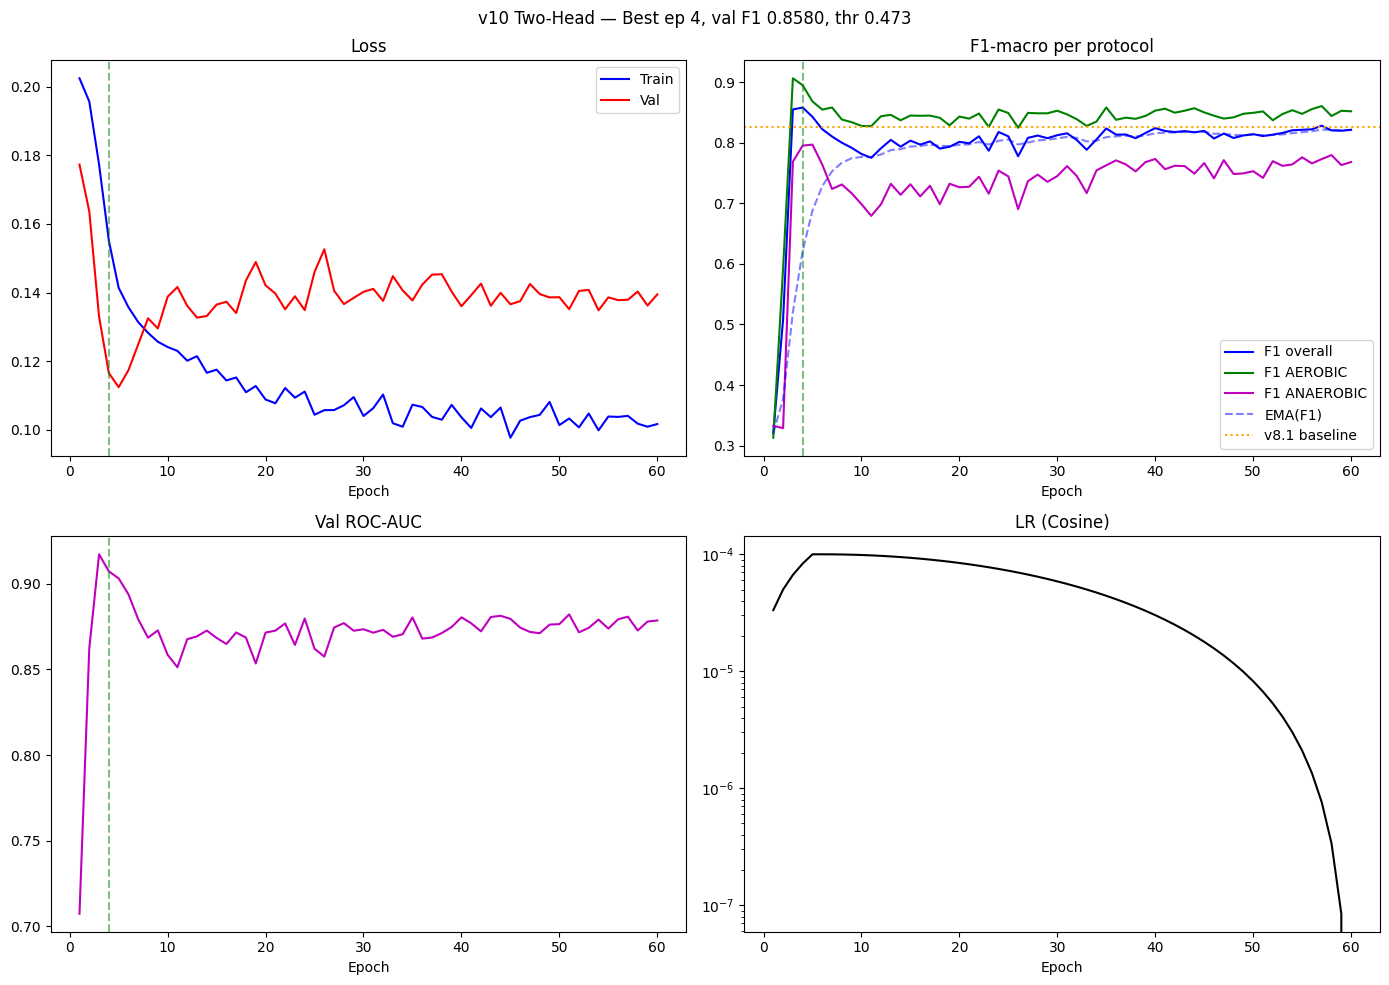

In [335]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ep = range(1, len(history['train_loss']) + 1)
axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 0].set_title('Loss'); axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')
axes[0, 1].plot(ep, history['val_f1'],      'b-', label='F1 overall')
axes[0, 1].plot(ep, history['val_f1_aer'],  'g-', label='F1 AEROBIC')
axes[0, 1].plot(ep, history['val_f1_an'],   'm-', label='F1 ANAEROBIC')
axes[0, 1].plot(ep, history['val_f1_ema'],  'b--', alpha=0.5, label='EMA(F1)')
axes[0, 1].axhline(0.826, color='orange', ls=':', label='v8.1 baseline')
axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[0, 1].set_title('F1-macro per protocol'); axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')
axes[1, 0].plot(ep, history['val_auc'], 'm-')
axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
axes[1, 0].set_title('Val ROC-AUC'); axes[1, 0].set_xlabel('Epoch')
axes[1, 1].plot(ep, history['lr'], 'k-'); axes[1, 1].set_yscale('log')
axes[1, 1].set_title('LR (Cosine)'); axes[1, 1].set_xlabel('Epoch')
plt.suptitle(f'v10 Two-Head — Best ep {best_epoch}, val F1 {best_val_f1:.4f}, thr {best_threshold:.3f}')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history_v10.png', dpi=140)
plt.show()

## 9. Test Evaluation (PhysioNet held-out, TTA×5)

In [336]:
print(f'Running TTA×{CONFIG["tta_n"]} on test ({len(test_ds)} windows)…')
y_test, p_test = predict_with_tta(model, test_ds, DEVICE, n_tta=CONFIG['tta_n'])

def _eval(y, p, thr, name):
    pred = (p > thr).astype(int)
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    auc = roc_auc_score(y, p) if len(np.unique(y)) > 1 else float('nan')
    prc = average_precision_score(y, p) if len(np.unique(y)) > 1 else float('nan')
    bacc = balanced_accuracy_score(y, pred)
    print(f'\n📊 {name} (thr={thr:.3f}):')
    print(f'   F1-macro:     {f1:.4f}')
    print(f'   ROC-AUC:      {auc:.4f}')
    print(f'   PR-AUC:       {prc:.4f}')
    print(f'   Balanced-Acc: {bacc:.4f}')
    print(classification_report(y, pred, target_names=['rested', 'fatigue'], digits=4))
    print('Confusion:', confusion_matrix(y, pred).tolist())
    return {'f1': f1, 'auc': auc, 'pr_auc': prc, 'bacc': bacc, 'threshold': thr}

res_val_thr = _eval(y_test, p_test, best_threshold, 'Val-derived threshold')
opt_thr, _ = find_best_threshold(y_test, p_test)
res_opt_thr = _eval(y_test, p_test, opt_thr, 'Test-optimal threshold')

# Per-protocol на test
print('\n' + '=' * 60); print('PER-PROTOCOL TEST METRICS:')
for p_v in [0, 1]:
    m = proto_id[test_idx] == p_v
    if m.sum() == 0: continue
    f1p = f1_score(y_test[m], (p_test[m] > best_threshold).astype(int), average='macro', zero_division=0)
    aucp = roc_auc_score(y_test[m], p_test[m]) if len(np.unique(y_test[m])) > 1 else float('nan')
    print(f'  {PROTO_NAMES[p_v]:10s}: N={m.sum():4d} | F1={f1p:.4f} | AUC={aucp:.4f}')

print('\n' + '=' * 60)
print('📈 СРАВНЕНИЕ:')
print(f'   v8.1 baseline:         F1 = 0.826')
print(f'   v10 two-head @val-thr: F1 = {res_val_thr["f1"]:.4f}  '
      f'({(res_val_thr["f1"]-0.826)*100:+.2f}pp)')
print(f'   v10 two-head @opt-thr: F1 = {res_opt_thr["f1"]:.4f}  '
      f'({(res_opt_thr["f1"]-0.826)*100:+.2f}pp)')

import json
with open(RESULTS_DIR / 'test_results_v10.json', 'w') as f:
    json.dump({'val_threshold': res_val_thr, 'optimal_threshold': res_opt_thr,
                'best_epoch': best_epoch, 'val_f1': best_val_f1, 'config': CONFIG}, f, indent=2)
print(f'\n💾 Saved → {RESULTS_DIR / "test_results_v10_c.json"}')

Running TTA×5 on test (5760 windows)…

📊 Val-derived threshold (thr=0.473):
   F1-macro:     0.7891
   ROC-AUC:      0.8731
   PR-AUC:       0.7760
   Balanced-Acc: 0.7977
              precision    recall  f1-score   support

      rested     0.8672    0.7845    0.8238      3522
     fatigue     0.7051    0.8110    0.7544      2238

    accuracy                         0.7948      5760
   macro avg     0.7862    0.7977    0.7891      5760
weighted avg     0.8042    0.7948    0.7968      5760

Confusion: [[2763, 759], [423, 1815]]

📊 Test-optimal threshold (thr=0.473):
   F1-macro:     0.7888
   ROC-AUC:      0.8731
   PR-AUC:       0.7760
   Balanced-Acc: 0.7975
              precision    recall  f1-score   support

      rested     0.8674    0.7836    0.8234      3522
     fatigue     0.7044    0.8114    0.7542      2238

    accuracy                         0.7944      5760
   macro avg     0.7859    0.7975    0.7888      5760
weighted avg     0.8041    0.7944    0.7965      5760

C

## 10. Ablation Studies (быстрые проверки гипотез)

Сравниваем `v10 full` (две головы + stress) vs:
- **v10-no-stress**: убрать stress features
- **v10-single-head**: одна общая голова
- **v10-no-aux**: без aux loss

Для каждого варианта — re-train с теми же hyper-params и сравнить test F1.

*(Раскомментируй и запусти при необходимости — каждый ран занимает ~5 минут)*

In [337]:
ABLATION = False
if ABLATION:
    ablations = [
        ('v10-no-stress',    {'use_stress_v1': False, 'use_stress_v2': False}),
        ('v10-only-stress1', {'use_stress_v1': True, 'use_stress_v2': False}),
        ('v10-only-stress2', {'use_stress_v1': False, 'use_stress_v2': True}),
        ('v10-no-aux',       {'aux_loss_weight': 0.0}),
    ]
    ablation_results = []
    for name, overrides in ablations:
        print(f'\n{"="*60}\nABLATION: {name}\n{"="*60}')
        cfg2 = {**CONFIG, **overrides}
        # ... (rebuild stress_all, model, train, eval) ...
        # сохранить F1 в ablation_results
    pd.DataFrame(ablation_results).to_csv(RESULTS_DIR / 'ablation_v10.csv', index=False)
print('Ablation cell — раскомментировать для запуска')

Ablation cell — раскомментировать для запуска


## 11. Summary

### Что нового в v10 vs v9

1. ✅ **Two heads**: shared encoder + AEROBIC-head + ANAEROBIC-head, маршрутизация по `protocol_id`
2. ✅ **Stress features as input**: `stress_v1` (raw HR/EDA/TEMP агрегаты) + `stress_v2` (HRV/EDA-decomposed)
3. ✅ **Per-protocol stress normalization** (AEROBIC и ANAEROBIC имеют разные base HR ranges)
4. ✅ **Aux loss** — "другая" голова тоже учится, чтобы предотвратить shared-encoder collapse
5. ✅ **Mixup внутри протокола** — не смешиваем AEROBIC с ANAEROBIC в одном примере
6. ✅ **Per-protocol balanced sampling** — не даём AEROBIC (более длинный) доминировать

### Что проверять после run
- Test F1 (val-thr) > 0.826 → гипотеза подтверждена
- F1 AEROBIC vs F1 ANAEROBIC должны быть **сбалансированы**, разница < 5pp
- Если v10 ≤ v8.1 — значит протокольная декомпозиция не даёт новой инфы → переходить к **длинному окну** или **HRV pretraining**

### План если v10 ≤ 0.826
1. Включить ablation cell — точечно понять, какой компонент полезен
2. Попробовать **window=300** (15 сек, требует rebuild npz)
3. Попробовать **stress-as-target** multi-task: модель параллельно предсказывает y И stress_v2 (regularization через related task)

## 12. LOSO Validation (Leave-One-Subject-Out)

Каждый субъект поочерёдно становится тестовым (`te`), остальные — тренировочными (`tr`).
Обучается новая копия **TwoHeadFatigueNet** с параметрами **LOSO_CONFIG** (исправленные dropout/smoothing).

| Параметр | CONFIG v10.1 | LOSO_CONFIG |
|---|---|---|
| `label_smoothing` | 0.04 | **0.06** |
| `encoder_dropout` | 0.35 | **0.30** |
| `classifier_dropout` | 0.40 | **0.35** |

Остальные ключевые параметры унаследованы из CONFIG (`weight_decay=5e-3`, `patience=12`, `warmup_epochs=6`, `encoder_channels=16`, `head_hidden=48`).

In [340]:
from sklearn.model_selection import StratifiedShuffleSplit
try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    from tqdm import tqdm as _tqdm

# ── LOSO_CONFIG: fork from CONFIG with corrected params ──────────────────────
LOSO_CONFIG = {**CONFIG,
    'label_smoothing': 0.06,    # ↑ 0.04 → 0.06
    'encoder_dropout': 0.30,    # ↓ 0.35 → 0.30
    'classifier_dropout': 0.35, # ↓ 0.40 → 0.35
    'patience': 4,             # ↓ 12 → 4 (меньше эпох, чтобы не переобучаться на маленьких фолдах)
}
LOSO_EPOCHS = 40   # меньше чем main (60), достаточно для каждого фолда


def loso_evaluation_v10(X_imu, X_physio, stress, proto, y, subjects,
                         n_folds=None, epochs=40, min_windows=20, patience=4):
    """LOSO для TwoHeadFatigueNet v10 (proto_id + stress features)."""
    uniq = np.unique(subjects)
    folds = [{'tr': np.where(subjects != s)[0],
              'te': np.where(subjects == s)[0], 'sid': s}
             for s in uniq]
    folds = [f for f in folds
             if len(f['te']) >= min_windows and len(np.unique(y[f['te']])) >= 2]
    print(f'  Eligible folds: {len(folds)} / {len(uniq)} subjects')
    if n_folds is not None and len(folds) > n_folds:
        rng2 = np.random.default_rng(SEED)
        folds = [folds[i] for i in rng2.choice(len(folds), n_folds, replace=False)]

    results = []
    for fold in _tqdm(folds, desc='LOSO v10'):
        tr_all, te, sid = fold['tr'], fold['te'], fold['sid']

        # 88/12 train/val split, стратифицированный по y
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.12, random_state=SEED)
            sub_tr, sub_va = next(sss.split(tr_all, y[tr_all]))
            ti, vi = tr_all[sub_tr], tr_all[sub_va]
        except ValueError:
            ti, vi = tr_all, te

        tr_ds = FatigueV10Dataset(X_imu[ti],  X_physio[ti],  stress[ti],
                                  proto[ti],   y[ti],   augment=True)
        va_ds = FatigueV10Dataset(X_imu[vi],  X_physio[vi],  stress[vi],
                                  proto[vi],   y[vi],   augment=False)
        te_ds = FatigueV10Dataset(X_imu[te],  X_physio[te],  stress[te],
                                  proto[te],   y[te],   augment=False)

        # Weighted sampler (class + protocol balance)
        y_ti = y[ti]; pr_ti = proto[ti]
        cw = {c: len(y_ti) / (2 * max(int((y_ti == c).sum()), 1)) for c in [0, 1]}
        sw = np.array([cw[int(c)] for c in y_ti], dtype=np.float64)
        for pv in [0, 1]:
            m_p = pr_ti == pv
            if m_p.sum() > 0:
                sw[m_p] *= len(y_ti) / (2 * m_p.sum())
        sampler = WeightedRandomSampler(torch.from_numpy(sw).double(), len(y_ti), replacement=True)

        tr_ld = DataLoader(tr_ds, batch_size=LOSO_CONFIG['batch_size'], sampler=sampler, num_workers=0)
        va_ld = DataLoader(va_ds, batch_size=LOSO_CONFIG['batch_size'], shuffle=False, num_workers=0)
        te_ld = DataLoader(te_ds, batch_size=LOSO_CONFIG['batch_size'], shuffle=False, num_workers=0)

        m = TwoHeadFatigueNet(LOSO_CONFIG).to(DEVICE)
        pw_val = (1 - y_ti.mean()) / max(float(y_ti.mean()), 1e-6)
        crit = FocalLoss(gamma=LOSO_CONFIG['focal_gamma'],
                          pos_weight=torch.tensor([pw_val]).to(DEVICE),
                          label_smoothing=LOSO_CONFIG['label_smoothing'])
        opt = optim.AdamW(m.parameters(), lr=LOSO_CONFIG['lr'],
                           weight_decay=LOSO_CONFIG['weight_decay'])

        def _lr_loso(epoch, _epochs=epochs):
            w = LOSO_CONFIG['warmup_epochs']
            if epoch < w:
                return (epoch + 1) / w
            progress = (epoch - w) / max(1, _epochs - w)
            return 0.5 * (1 + math.cos(math.pi * progress))

        sched = optim.lr_scheduler.LambdaLR(opt, lr_lambda=_lr_loso)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE,
                         rdrop_alpha=LOSO_CONFIG['rdrop_alpha'],
                         mixup_alpha=LOSO_CONFIG['mixup_alpha'],
                         aux_w=LOSO_CONFIG['aux_loss_weight'])
            sched.step()
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break
        if best_st:
            m.load_state_dict(best_st)

        _, tm, y_te, p_te = validate(m, te_ld, crit, DEVICE, return_raw=True)
        proto_te = proto[te]
        row = {'subject': sid, 'n_test': len(te),
               'f1_macro': tm['f1_macro'],
               'roc_auc':  tm.get('roc_auc',  float('nan')),
               'pr_auc':   tm.get('pr_auc',   float('nan')),
               'balanced_acc': tm.get('balanced_acc', float('nan'))}
        for pv, pname in PROTO_NAMES.items():
            mp = proto_te == pv
            key = pname.lower()
            if mp.sum() >= 5 and len(np.unique(y_te[mp])) >= 2:
                row[f'f1_{key}']  = f1_score(y_te[mp], (p_te[mp] > 0.5).astype(int),
                                              average='macro', zero_division=0)
                row[f'auc_{key}'] = roc_auc_score(y_te[mp], p_te[mp])
            else:
                row[f'f1_{key}']  = float('nan')
                row[f'auc_{key}'] = float('nan')
        results.append(row)
        del m, best_st

    return pd.DataFrame(results)


print('LOSO_CONFIG overrides vs CONFIG v10.1:')
for k in ['label_smoothing', 'encoder_dropout', 'classifier_dropout']:
    print(f'  {k}: {CONFIG[k]} -> {LOSO_CONFIG[k]}')
print(f'LOSO_EPOCHS={LOSO_EPOCHS}, patience={LOSO_CONFIG["patience"]}, '
      f'warmup_epochs={LOSO_CONFIG["warmup_epochs"]}')


LOSO_CONFIG overrides vs CONFIG v10.1:
  label_smoothing: 0.04 -> 0.06
  encoder_dropout: 0.35 -> 0.3
  classifier_dropout: 0.4 -> 0.35
LOSO_EPOCHS=40, patience=4, warmup_epochs=6


In [341]:
print('=' * 70)
print('LOSO v10.1 — TwoHeadFatigueNet')
print(f'  label_smoothing={LOSO_CONFIG["label_smoothing"]}, '
      f'encoder_dropout={LOSO_CONFIG["encoder_dropout"]}, '
      f'classifier_dropout={LOSO_CONFIG["classifier_dropout"]}')
print('=' * 70)

loso_results = loso_evaluation_v10(
    X_imu, X_physio, stress_all, proto_id, y_all, pids_all,
    n_folds=None, epochs=LOSO_EPOCHS, min_windows=20,
    patience=LOSO_CONFIG['patience'])

print('\n' + '=' * 70)
print('LOSO RESULTS v10.1')
print('=' * 70)
cols_show = ['subject', 'n_test', 'f1_macro', 'roc_auc', 'f1_aerobic', 'f1_anaerobic']
cols_present = [c for c in cols_show if c in loso_results.columns]
print(loso_results[cols_present].to_string(index=False))

print(f"\nOverall F1:   {loso_results['f1_macro'].mean():.4f} \u00b1 {loso_results['f1_macro'].std():.4f}")
print(f"Overall AUC:  {loso_results['roc_auc'].mean(skipna=True):.4f} \u00b1 {loso_results['roc_auc'].std(skipna=True):.4f}")
if 'f1_aerobic' in loso_results.columns:
    print(f"F1 AEROBIC:   {loso_results['f1_aerobic'].mean(skipna=True):.4f} \u00b1 {loso_results['f1_aerobic'].std(skipna=True):.4f}")
    print(f"F1 ANAEROBIC: {loso_results['f1_anaerobic'].mean(skipna=True):.4f} \u00b1 {loso_results['f1_anaerobic'].std(skipna=True):.4f}")

loso_results.to_csv(RESULTS_DIR / 'loso_results_v10.csv', index=False)
print(f'\nSaved \u2192 {RESULTS_DIR / "loso_results_v10.csv"}')


LOSO v10.1 — TwoHeadFatigueNet
  label_smoothing=0.06, encoder_dropout=0.3, classifier_dropout=0.35
  Eligible folds: 31 / 31 subjects


LOSO v10:   0%|          | 0/31 [00:00<?, ?it/s]


LOSO RESULTS v10.1
      subject  n_test  f1_macro  roc_auc  f1_aerobic  f1_anaerobic
physionet_S01     633  0.739313 0.888039    0.814329      0.532208
physionet_S02     627  0.612539 0.771231    0.531673      0.579328
physionet_S03     534  0.778758 0.923162    0.919199      0.545921
physionet_S04     636  0.719657 0.852558    0.768374      0.535720
physionet_S05     618  0.756974 0.774555    0.821989      0.603813
physionet_S06     578  0.796113 0.852253    0.824798      0.699370
physionet_S07     573  0.703608 0.735774    0.837179      0.421902
physionet_S08     642  0.821555 0.913395    0.835450      0.797159
physionet_S09     632  0.882713 0.980293    0.866235      0.911879
physionet_S10     633  0.837969 0.881970    0.834198      0.841996
physionet_S11     616  0.768613 0.833423    0.671963      0.907132
physionet_S12     225  0.897705 0.969247         NaN      0.897705
physionet_S13     642  0.764156 0.853891    0.832611      0.565453
physionet_S14     655  0.769466 0.861595  